Data Set used is Kaggle Spoken Digit Dataset : https://www.kaggle.com/divyanshu99/spoken-digit-dataset

In [1]:
!pip install --user hmmlearn
!pip show hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.5 MB/s eta 0:00:00
Name: hmmlearn
Version: 0.3.3
Summary: Hidden Markov Models in Python with scikit-learn like API
Home-page: 
Author: David Cournapeau, Fabian Pedregosa, Gael Varoquaux, Sergei Lebedev, Antony Lee, Matthew Danielson
Author-email: 
License: 
Location: /root/.local/lib/python3.12/site-packages
Requires: numpy, scikit-learn, scipy
Required-by: 


In [5]:
import sys
sys.path.append(r'/root/.local/lib/python3.12/site-packages')

In [6]:
from hmmlearn import hmm

In [7]:
import warnings
import os
import numpy as np
from librosa.feature import mfcc
import librosa
import random

[os.listdir(path)](https://www.tutorialspoint.com/python/os_listdir.htm)


[os.path.splitext(path)](https://docs.python.org/2/library/os.path.html)

In [16]:
def buildDataSet(dir,rte):
    # Filter out the wav audio files under the dir
    fileList = [f for f in os.listdir(dir) if os.path.splitext(f)[1] == '.wav']
    train_dataset = {}
    test_dataset = {}
    cnt=1
    # Calculate percent of each train and test
    nm = int(rte*50)
    rnd = random.sample(range(0,50), nm)

    for fileName in fileList:
        label = fileName.split('_')[0]
        # feature = extract_mfcc(dir+fileName).T #extract 20 mfcc for each file and each mfcc has different length
        feature = extract_mfcc(os.path.join(dir, fileName)).T
        if cnt in rnd:
            if label not in test_dataset.keys():
                test_dataset[label] = []
                test_dataset[label].append(feature)
            else:
                exist_feature = test_dataset[label]
                exist_feature.append(feature)
                test_dataset[label] = exist_feature
        else:
            if label not in train_dataset.keys():
                train_dataset[label] = []
                train_dataset[label].append(feature)
            else:
                exist_feature = train_dataset[label]
                exist_feature.append(feature)
                train_dataset[label] = exist_feature
        if (cnt == 50):
            cnt = 1
            rnd = random.sample(range(0, 50), 12)
        else:
            cnt += 1
    return train_dataset,test_dataset

In [20]:
def extract_mfcc(full_audio_path):
    wave, sample_rate = librosa.load(full_audio_path)
    mfcc_features = librosa.feature.mfcc(y=wave, sr=sample_rate)
    return mfcc_features

In [10]:
### Gussian HMM
def train_HMM(dataset):
    Models = {}
    for label in dataset.keys():
        model = hmm.GMMHMM(n_components=5, n_iter = 50)
        trainData = dataset[label]
        trData = np.vstack(trainData)
        model.fit(trData)
        Models[label] = model
    return Models

In [11]:
### ignore warning message of readfile
warnings.filterwarnings('ignore')

In [13]:
import zipfile
import os

# Path to your zip file in Colab
zip_path = '/content/archive.zip'

# Folder where files will be extracted
extract_path = '/content/archive_extracted'

# Create the folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Files extracted to:", extract_path)
print("📂 Extracted items:", os.listdir(extract_path))


✅ Files extracted to: /content/archive_extracted
📂 Extracted items: ['free-spoken-digit-dataset-master']


In [21]:
### Step.1 Loading data
trainDir = '/content/archive_extracted/free-spoken-digit-dataset-master/recordings'
print('Step.1 data loading...')
trainDataSet,testDataSet = buildDataSet(trainDir,rte=0.25)
print("Finish prepare the data")

Step.1 data loading...
Finish prepare the data


In [22]:
print('printing number of train data for each label ...')
for key, value in trainDataSet.items():
  print('Digit ' + str(key)+ ' has ' + str(len(value)) + ' Training observations')

printing number of train data for each label ...
Digit 0 has 114 Training observations
Digit 6 has 109 Training observations
Digit 4 has 113 Training observations
Digit 5 has 107 Training observations
Digit 7 has 119 Training observations
Digit 1 has 119 Training observations
Digit 3 has 119 Training observations
Digit 9 has 116 Training observations
Digit 2 has 119 Training observations
Digit 8 has 111 Training observations


In [23]:
print('printing number of test data for each label ...')
for key, value in testDataSet.items():
  print('Digit ' + str(key)+ ' has ' + str(len(value)) + ' Testing observations')

printing number of test data for each label ...
Digit 0 has 36 Testing observations
Digit 9 has 34 Testing observations
Digit 6 has 41 Testing observations
Digit 5 has 43 Testing observations
Digit 3 has 31 Testing observations
Digit 1 has 31 Testing observations
Digit 8 has 39 Testing observations
Digit 4 has 37 Testing observations
Digit 2 has 31 Testing observations
Digit 7 has 31 Testing observations


In [24]:
# observing the MFCC vectors of first Training data in label 0
print('MFCC-s of the first 0-Label Training data...')
print('It Consists of ' + str(trainDataSet['0'][0].shape[1]) + ' MFCC vectors')
print('And Each has ' + str(trainDataSet['0'][0].shape[0]) + ' cepstral coefficient')

MFCC-s of the first 0-Label Training data...
It Consists of 20 MFCC vectors
And Each has 21 cepstral coefficient


In [25]:
# observing the MFCC vectors of second Training data in label 0
print('MFCC-s of the second 0-Label Training data...')
print('It Consists of ' + str(trainDataSet['0'][1].shape[1]) + ' MFCC vectors')
print('And Each has ' + str(trainDataSet['0'][1].shape[0]) + ' cepstral coefficient')

MFCC-s of the second 0-Label Training data...
It Consists of 20 MFCC vectors
And Each has 20 cepstral coefficient


In [26]:
### Step.2 Training
print('Step.2 Training model...')
hmmModels = train_HMM(trainDataSet)
print("Finish training of the GMM_HMM models for digits 0-9")

Step.2 Training model...
Finish training of the GMM_HMM models for digits 0-9


In [27]:
### Step.3 predict test data
acc_count = 0
all_data_count = 0
for label in testDataSet.keys():
  feature = testDataSet[label]
  for index in range(len(feature)):
    all_data_count+=1
    scoreList = {}
    for model_label in hmmModels.keys():
      model = hmmModels[model_label]
      score = model.score(feature[index])
      scoreList[model_label] = score
    predict = max(scoreList, key=scoreList.get)
    if predict == label:
      acc_count+=1

accuracy = round(((acc_count/all_data_count)*100.0),3)

print("\n##########################################################################")
print("######################## A-C-C-U-R-A-C-Y #################################")
print("########################    ",accuracy,"%","   #################################")
print("##########################################################################")


##########################################################################
######################## A-C-C-U-R-A-C-Y #################################
########################     96.61 %    #################################
##########################################################################


In [29]:
### Question 1: What is the sampling rate of the wav files?

print("=" * 80)
print("QUESTION 1: SAMPLING RATE OF WAV FILES")
print("=" * 80)

sample_audio = os.path.join(trainDir, os.listdir(trainDir)[0])
wave, sample_rate = librosa.load(sample_audio)
print(f"\nSampling Rate: {sample_rate} Hz")
print(f"Sample Audio File: {os.listdir(trainDir)[0]}")
print("=" * 80)


QUESTION 1: SAMPLING RATE OF WAV FILES

Sampling Rate: 22050 Hz
Sample Audio File: 0_jackson_37.wav


In [31]:
### Question 2: Find maximum and minimum duration of each spoken digit

print("=" * 80)
print("QUESTION 2: MAXIMUM AND MINIMUM DURATION FOR EACH DIGIT")
print("=" * 80)

durations = {}
for label in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']:
    durations[label] = []

# Get all wav files and calculate durations
fileList = [f for f in os.listdir(trainDir) if os.path.splitext(f)[1] == '.wav']
for fileName in fileList:
    label = fileName.split('_')[0]
    wave, sr = librosa.load(os.path.join(trainDir, fileName))  # Fixed this line
    duration = len(wave) / sr  # duration in seconds
    durations[label].append(duration)

print(f"\n{'Digit':<10} {'Min Duration (s)':<20} {'Max Duration (s)':<20} {'Avg Duration (s)':<20}")
print("-" * 80)
for label in sorted(durations.keys()):
    min_dur = min(durations[label])
    max_dur = max(durations[label])
    avg_dur = sum(durations[label]) / len(durations[label])
    print(f"{label:<10} {min_dur:<20.4f} {max_dur:<20.4f} {avg_dur:<20.4f}")
print("=" * 80)


QUESTION 2: MAXIMUM AND MINIMUM DURATION FOR EACH DIGIT

Digit      Min Duration (s)     Max Duration (s)     Avg Duration (s)    
--------------------------------------------------------------------------------
0          0.2826               0.7841               0.5013              
1          0.1945               0.7640               0.3846              
2          0.1610               0.7386               0.3760              
3          0.1819               0.5698               0.3570              
4          0.2040               0.6834               0.3695              
5          0.2092               1.0252               0.3978              
6          0.1436               0.8798               0.4778              
7          0.2457               2.1959               0.4226              
8          0.2257               0.6346               0.3861              
9          0.2223               2.2828               0.5092              


QUESTION 3: SCATTER PLOT OF FIRST TWO MFCC COEFFICIENTS (Digits 0 and 1)


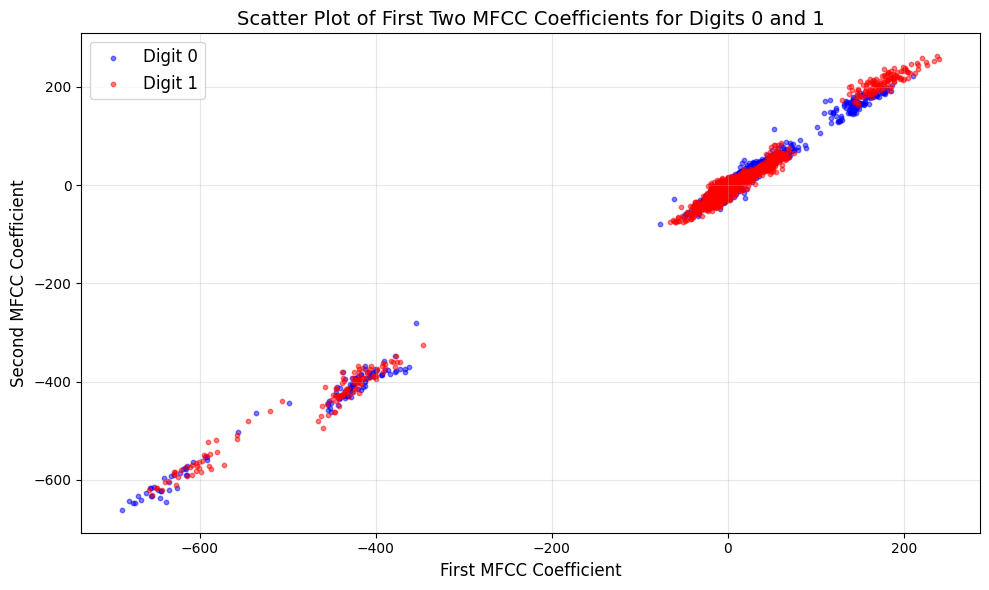


Total data points for Digit 0: 2280
Total data points for Digit 1: 2380


In [32]:
### Question 3: Scatter diagram of first and second MFCC for digits 0 and 1

import matplotlib.pyplot as plt

print("=" * 80)
print("QUESTION 3: SCATTER PLOT OF FIRST TWO MFCC COEFFICIENTS (Digits 0 and 1)")
print("=" * 80)

# Collect MFCC data for digits 0 and 1
mfcc_0_first = []
mfcc_0_second = []
mfcc_1_first = []
mfcc_1_second = []

# Get MFCC from training data
for feature in trainDataSet['0']:
    mfcc_0_first.extend(feature[0, :])  # First MFCC coefficient across all time frames
    mfcc_0_second.extend(feature[1, :])  # Second MFCC coefficient across all time frames

for feature in trainDataSet['1']:
    mfcc_1_first.extend(feature[0, :])
    mfcc_1_second.extend(feature[1, :])

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(mfcc_0_first, mfcc_0_second, c='blue', alpha=0.5, label='Digit 0', s=10)
plt.scatter(mfcc_1_first, mfcc_1_second, c='red', alpha=0.5, label='Digit 1', s=10)
plt.xlabel('First MFCC Coefficient', fontsize=12)
plt.ylabel('Second MFCC Coefficient', fontsize=12)
plt.title('Scatter Plot of First Two MFCC Coefficients for Digits 0 and 1', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal data points for Digit 0: {len(mfcc_0_first)}")
print(f"Total data points for Digit 1: {len(mfcc_1_first)}")
print("=" * 80)


In [33]:
### Question 4: How many states in the HMM?

print("=" * 80)
print("QUESTION 4: NUMBER OF STATES IN THE HMM")
print("=" * 80)

# Get number of components from the first model
first_model = hmmModels[list(hmmModels.keys())[0]]
n_states = first_model.n_components

print(f"\nNumber of Hidden States in each HMM: {n_states}")
print(f"\nNote: Each digit (0-9) has its own separate HMM model.")
print(f"      All models use {n_states} hidden states (n_components parameter).")
print(f"      Total models trained: {len(hmmModels)}")
print("=" * 80)


QUESTION 4: NUMBER OF STATES IN THE HMM

Number of Hidden States in each HMM: 5

Note: Each digit (0-9) has its own separate HMM model.
      All models use 5 hidden states (n_components parameter).
      Total models trained: 10


In [34]:
### Question 5: Testing accuracy of each digit

print("=" * 80)
print("QUESTION 5: TESTING ACCURACY FOR EACH DIGIT")
print("=" * 80)

digit_accuracy = {}
for label in testDataSet.keys():
    correct = 0
    total = 0
    feature = testDataSet[label]

    for index in range(len(feature)):
        total += 1
        scoreList = {}
        for model_label in hmmModels.keys():
            model = hmmModels[model_label]
            score = model.score(feature[index])
            scoreList[model_label] = score
        predict = max(scoreList, key=scoreList.get)
        if predict == label:
            correct += 1

    accuracy = (correct / total) * 100
    digit_accuracy[label] = (correct, total, accuracy)

print(f"\n{'Digit':<10} {'Correct':<15} {'Total':<15} {'Accuracy (%)':<15}")
print("-" * 80)
for label in sorted(digit_accuracy.keys()):
    correct, total, accuracy = digit_accuracy[label]
    print(f"{label:<10} {correct:<15} {total:<15} {accuracy:<15.2f}")

# Overall accuracy
total_correct = sum([d[0] for d in digit_accuracy.values()])
total_samples = sum([d[1] for d in digit_accuracy.values()])
overall_accuracy = (total_correct / total_samples) * 100
print("-" * 80)
print(f"{'Overall':<10} {total_correct:<15} {total_samples:<15} {overall_accuracy:<15.2f}")



QUESTION 5: TESTING ACCURACY FOR EACH DIGIT

Digit      Correct         Total           Accuracy (%)   
--------------------------------------------------------------------------------
0          36              36              100.00         
1          31              31              100.00         
2          31              31              100.00         
3          26              31              83.87          
4          37              37              100.00         
5          41              43              95.35          
6          41              41              100.00         
7          30              31              96.77          
8          36              39              92.31          
9          33              34              97.06          
--------------------------------------------------------------------------------
Overall    342             354             96.61          
